<a href="https://colab.research.google.com/github/sathviknanduri/Netflix-Content-Analysis/blob/main/NETFLIX_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INTRODUCTION


Netflix is a global leader in streaming entertainment with millions of subscribers worldwide.
The goal of this analysis is to explore the Netflix dataset to understand trends in content production,
genres, and country distribution. Insights from this data can help Netflix decide what type of shows or movies
to focus on and how to strengthen its presence across countries.


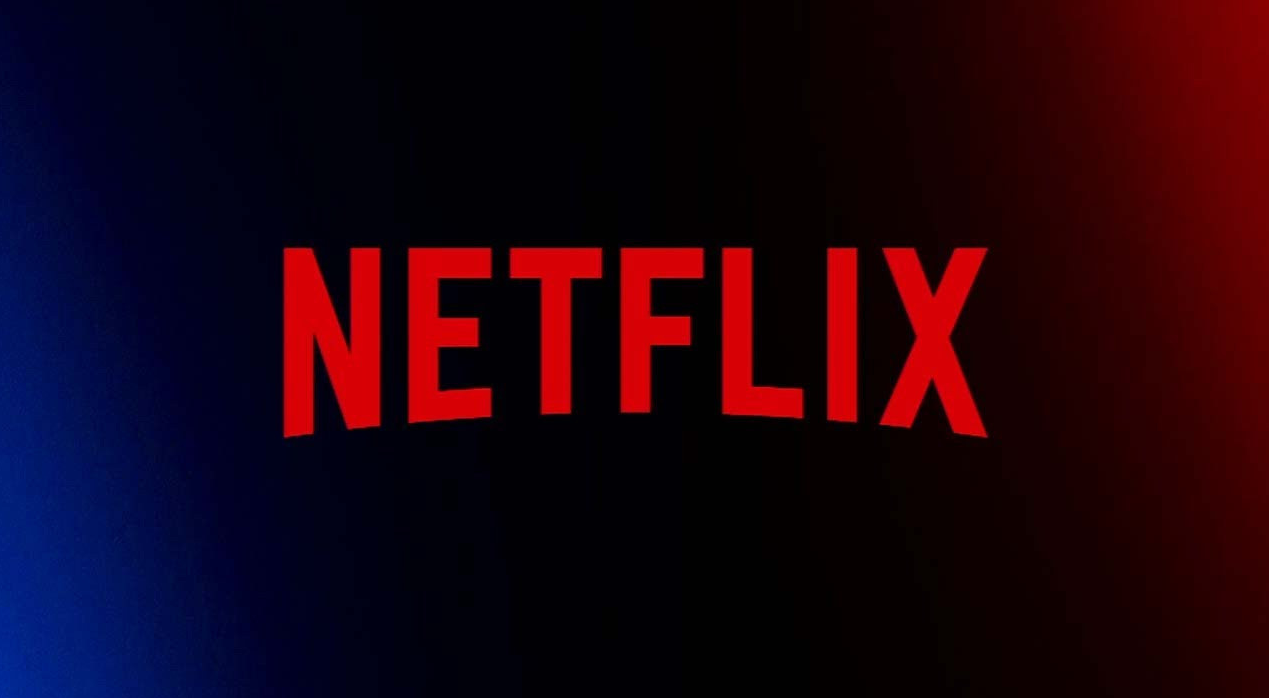

#PROBLEM STATEMENT

Netflix wants to determine which types of content (movies or TV shows) it should focus on and how it can grow its presence across different countries.
By exploring and visualizing the dataset, we aim to identify:

1. What kind of content is most popular across regions.

2. How content trends have evolved over time.

3. Which genres, directors, or actors dominate the platform.

4. Whether Netflix’s recent strategy leans more toward movies or TV shows.

# IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

#DATASET OVERVIEW

In [ ]:
file_path = "/content/netflix.csv"
df = pd.read_csv(file_path)
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)
print("\nData Types:\n")
df.info()

print("\nMissing Values:\n", df.isnull().sum())
print("\nSample Records:\n", df.head())


Dataset Shape: (8807, 12)

Column Names:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Data Types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing Values:
 sh

Columns:

* show_id: Unique ID for each title

* type: Movie or TV Show

* title: Name of the movie/show

* director: Director(s)

* cast: Main actors

* country: Production country

* date_added: Date added to Netflix

* release_year: Year of original release

* rating: Audience rating (e.g., TV-MA, PG-13)

* duration: Duration in minutes or seasons

* listed_in: Genre(s)

* description: Brief summary

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#DATASET EXPLANATION

The dataset includes categorical, datetime, and textual data.

* Categorical variables (type, rating, country, genre) help in grouping and frequency analysis.

* Datetime fields (date_added, release_year) are used to track temporal trends.

* Text fields (cast, description) can offer qualitative insights.

#DATA CLEANING PROCESS

#1. Check dataset information

* The dataset has 8807 rows and 12 columns.

* Columns with missing values:

    * director (30% missing)

    * cast (9% missing)

    * country (9% missing)

    * date_added (0.1% missing)

    * rating (0.05% missing)

    * duration (0.03% missing)

In [ ]:
import numpy as np
import pandas as pd

df.shape

(8807, 12)

#2. Remove duplicates

In [ ]:
df.drop_duplicates(inplace=True)


#3. Handle missing values

In [ ]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Not Available', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['date_added'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)
df['duration'].fillna('Unknown', inplace=True)


/tmp/ipython-input-3068075978.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipython-input-3068075978.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

#4. Convert data types

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


#5. Extract useful time features

In [ ]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


#6. Clean text columns

In [ ]:
text_cols = ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']
for col in text_cols:
    df[col] = df[col].str.strip()


#7. Separate numeric duration

In [ ]:
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_type'] = df['duration'].apply(lambda x: 'min' if 'min' in x else 'season')


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2262541333.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float)


# 8. Handle inconsistent country and genre lists

In [ ]:
df['country'] = df['country'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)
df['listed_in'] = df['listed_in'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)


#9. Final structure check

In [ ]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   object        
 2   title          8807 non-null   object        
 3   director       8807 non-null   object        
 4   cast           8807 non-null   object        
 5   country        8807 non-null   object        
 6   date_added     8709 non-null   datetime64[ns]
 7   release_year   8807 non-null   int64         
 8   rating         8807 non-null   object        
 9   duration       8807 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  year_added     8709 non-null   float64       
 13  month_added    8709 non-null   float64       
 14  duration_int   8804 non-null   float64       
 15  duration_type  8807 n

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


# 1. Univariate Analysis (One variable at a time)

Focus: Understand individual features — their distribution, frequency, or pattern.

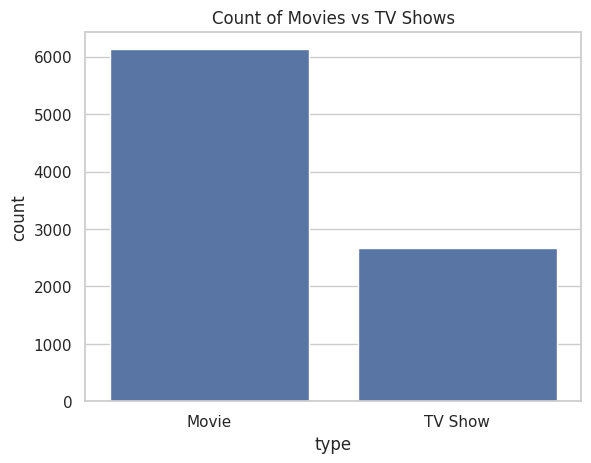

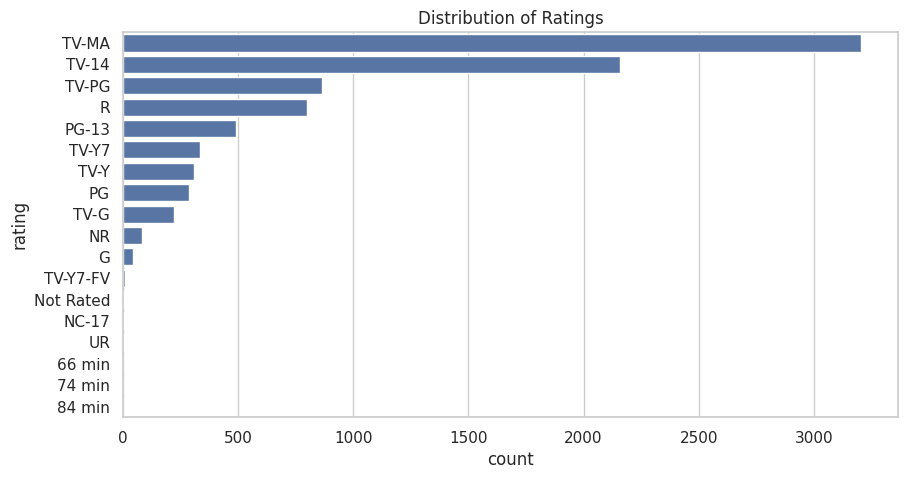

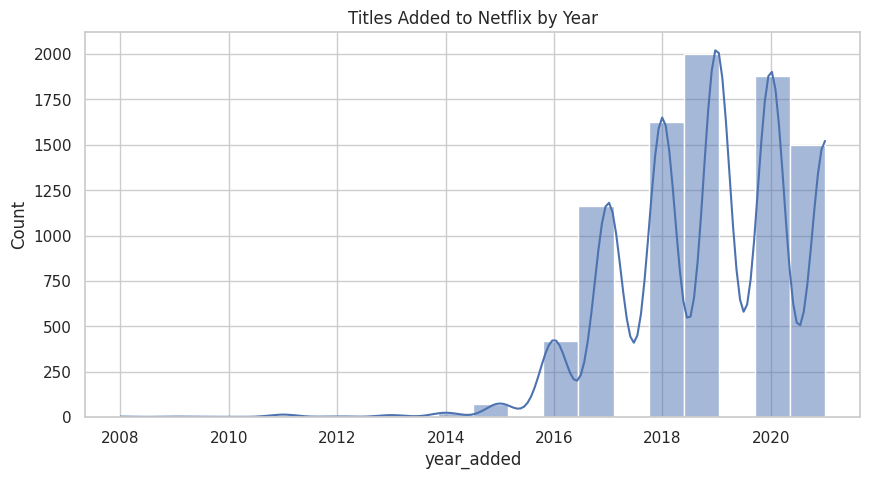

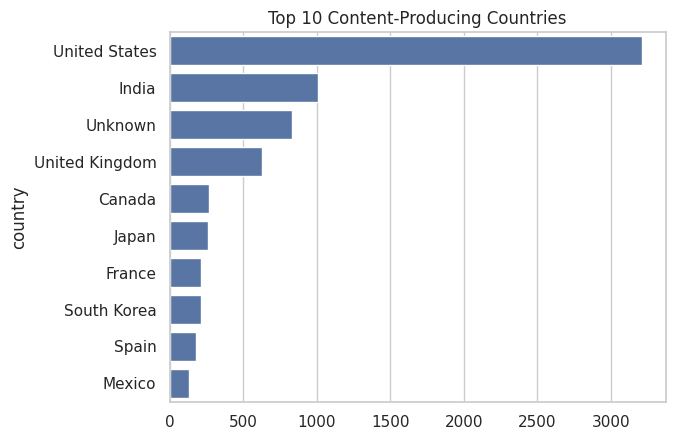

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Type count
sns.countplot(x='type', data=df)
plt.title('Count of Movies vs TV Shows')
plt.show()

# Rating distribution
plt.figure(figsize=(10,5))
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title('Distribution of Ratings')
plt.show()

# Year added
plt.figure(figsize=(10,5))
sns.histplot(df['year_added'].dropna(), bins=20, kde=True)
plt.title('Titles Added to Netflix by Year')
plt.show()

# Top 10 countries
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Content-Producing Countries')
plt.show()


# 2. Bivariate Analysis (Two variables)

Focus: Compare relationships or patterns between two variables.

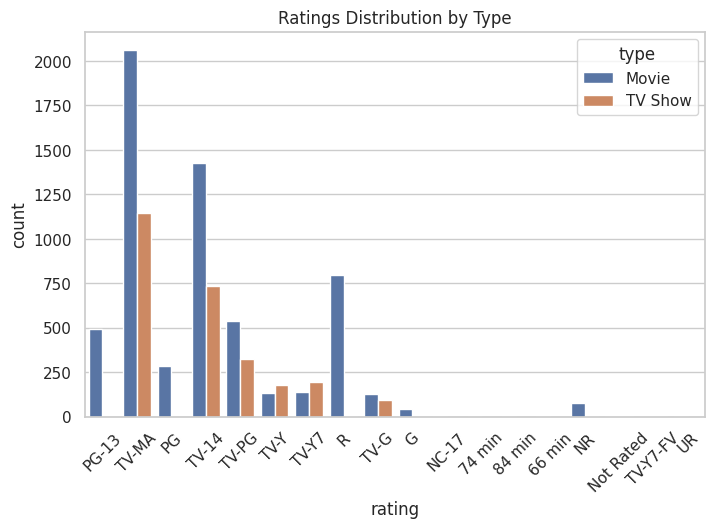

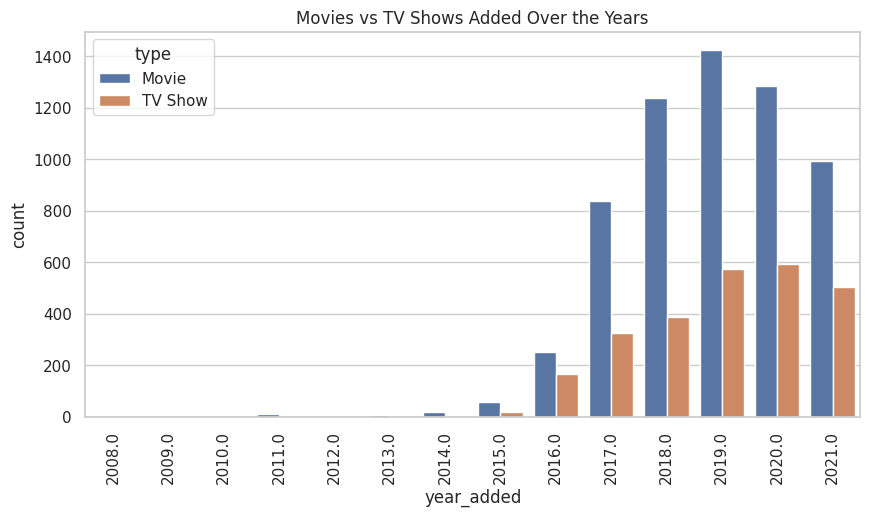

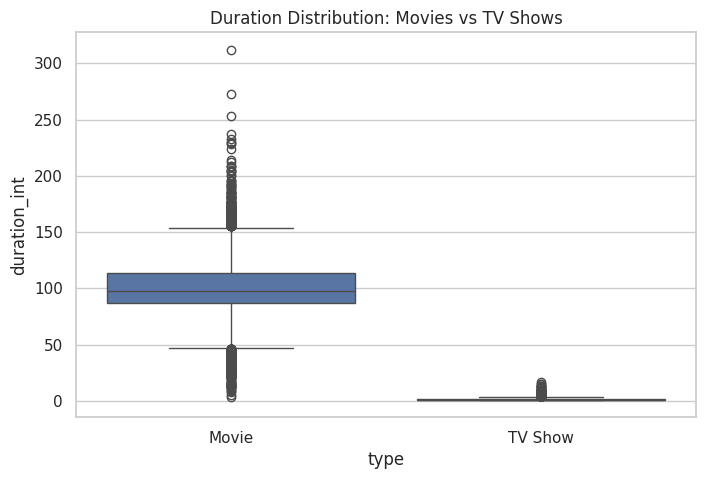

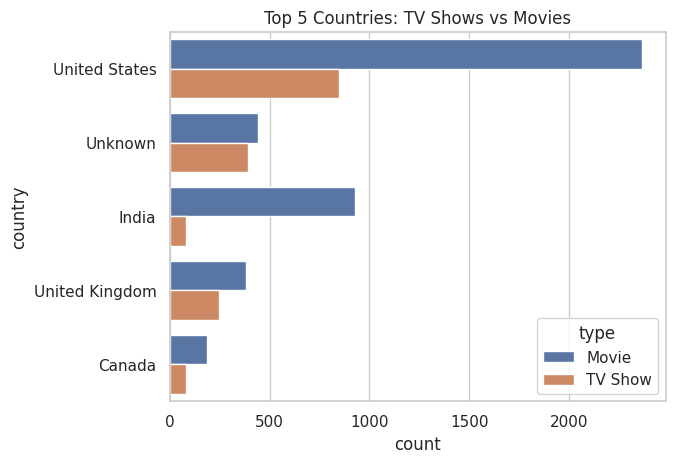

In [ ]:
# Type vs Rating
plt.figure(figsize=(8,5))
sns.countplot(x='rating', hue='type', data=df)
plt.title('Ratings Distribution by Type')
plt.xticks(rotation=45)
plt.show()

# Year added vs Type
plt.figure(figsize=(10,5))
sns.countplot(x='year_added', hue='type', data=df)
plt.title('Movies vs TV Shows Added Over the Years')
plt.xticks(rotation=90)
plt.show()

# Duration vs Type
plt.figure(figsize=(8,5))
sns.boxplot(x='type', y='duration_int', data=df)
plt.title('Duration Distribution: Movies vs TV Shows')
plt.show()

# Country vs Type (Top 5 countries)
top5 = df['country'].value_counts().index[:5]
sns.countplot(y='country', hue='type', data=df[df['country'].isin(top5)])
plt.title('Top 5 Countries: TV Shows vs Movies')
plt.show()


# 3. Multivariate Analysis (Three or more variables)

Focus: Explore relationships among multiple features together.

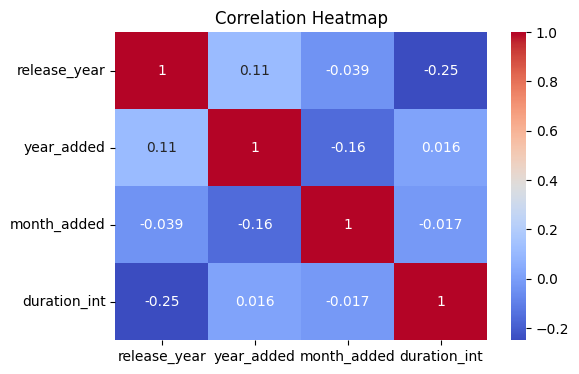

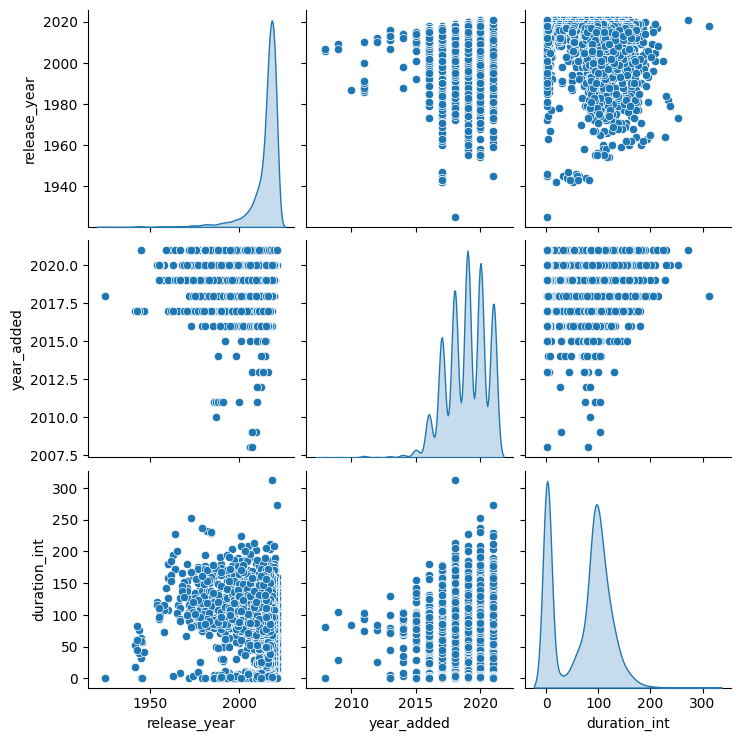

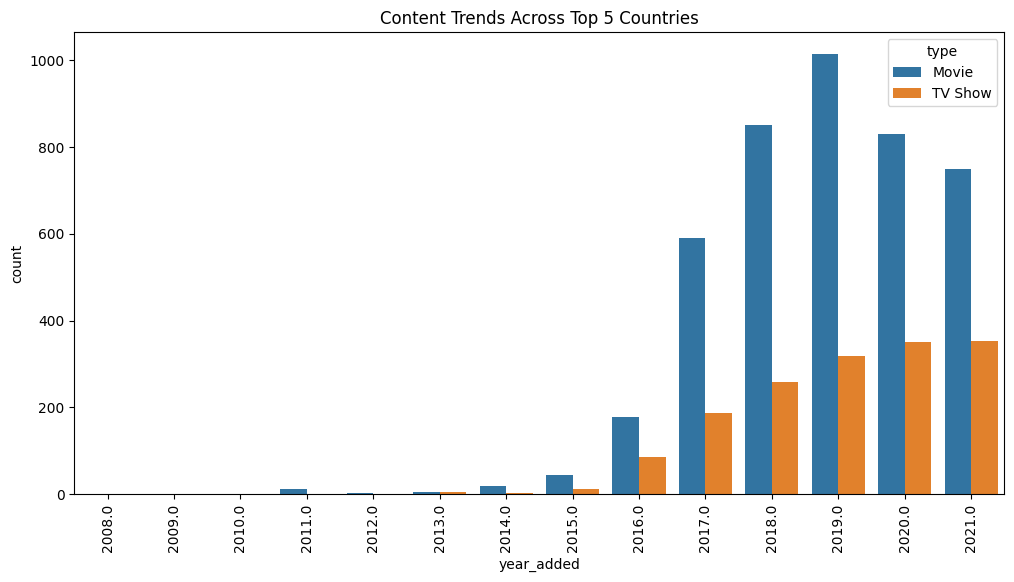

In [ ]:
# Correlation matrix (for numeric fields)
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Pairplot for numerical trends
sns.pairplot(df[['release_year', 'year_added', 'duration_int']], diag_kind='kde')
plt.show()

# Type vs Year Added vs Country
plt.figure(figsize=(12,6))
sns.countplot(x='year_added', hue='type', data=df[df['country'].isin(top5)])
plt.title('Content Trends Across Top 5 Countries')
plt.xticks(rotation=90)
plt.show()


# ANSWERS TO KEY QUESTIONS
#1. How has the number of movies released per year changed over the last 20-30 years?

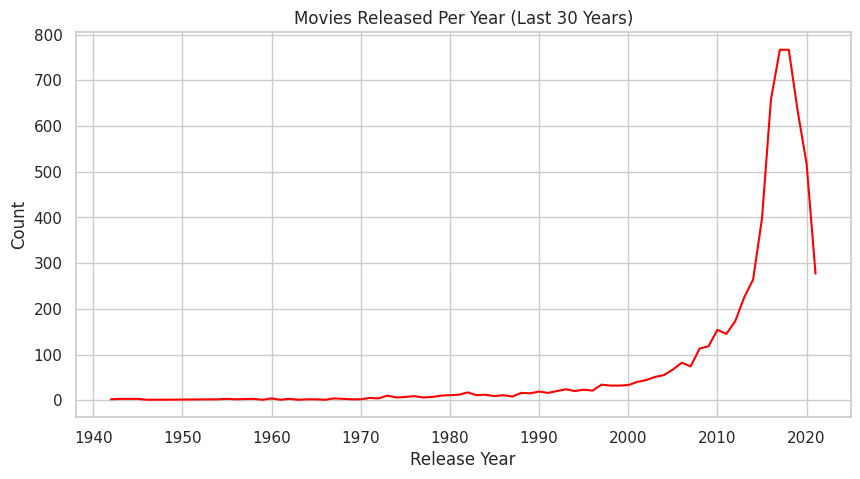

In [ ]:
plt.figure(figsize=(10,5))
movie_trend = df[df['type']=='Movie'].groupby('release_year').size()
movie_trend.plot(kind='line', color='red')
plt.title('Movies Released Per Year (Last 30 Years)')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

#2. Comparison of TV Shows vs Movies

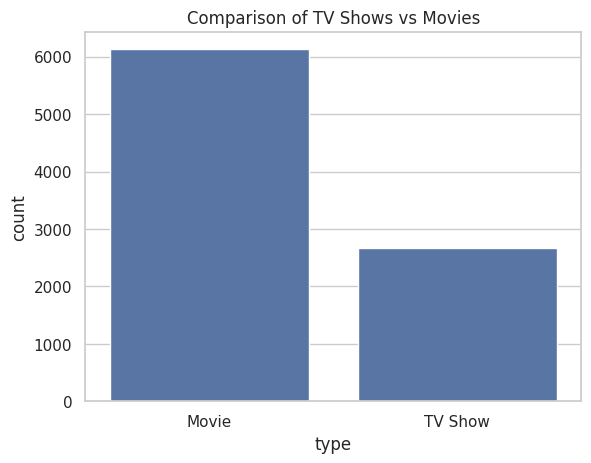

In [ ]:
sns.countplot(x='type', data=df)
plt.title('Comparison of TV Shows vs Movies')
plt.show()

#3. Best time to launch a TV show

/tmp/ipython-input-1080157611.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month_added', data=tv_shows, palette='coolwarm')


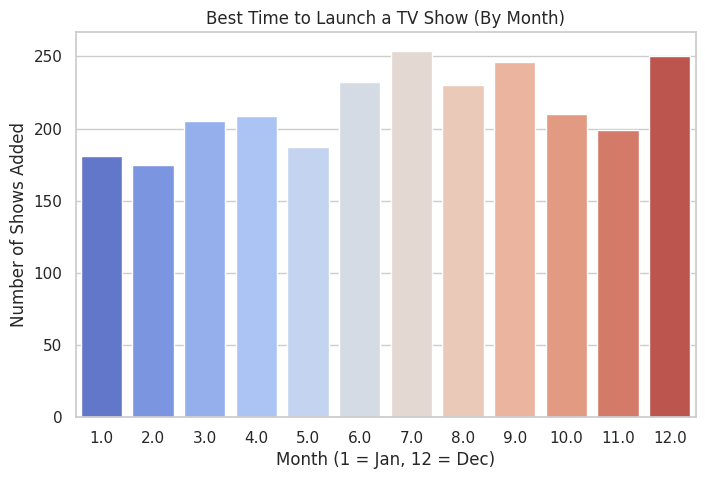

In [ ]:
# Ensure 'month_added' exists and is numeric
if 'month_added' not in df.columns:
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['month_added'] = df['date_added'].dt.month

# Drop rows where month_added is NaN
tv_shows = df[(df['type'] == 'TV Show') & (df['month_added'].notnull())]

# Now plot
plt.figure(figsize=(8,5))
sns.countplot(x='month_added', data=tv_shows, palette='coolwarm')
plt.title('Best Time to Launch a TV Show (By Month)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Number of Shows Added')
plt.show()


# 4. Analysis of actors/directors of different types

In [ ]:
from collections import Counter

# Handle missing values properly before counting
df['director'] = df['director'].fillna('Unknown').astype(str)
df['cast'] = df['cast'].fillna('Not Available').astype(str)

# Top 10 directors
top_directors = Counter(df['director']).most_common(10)
print("Top 10 Directors:")
for name, count in top_directors:
    print(f"{name}: {count}")

# Top 10 actors
# Only join if all entries are strings
all_casts = ','.join(df['cast'].astype(str).tolist())
top_cast = Counter([c.strip() for c in all_casts.split(',') if c.strip() not in ['Not Available', '']]).most_common(10)

print("\nTop 10 Actors:")
for name, count in top_cast:
    print(f"{name}: {count}")


Top 10 Directors:
Unknown: 2634
Rajiv Chilaka: 19
Raúl Campos, Jan Suter: 18
Suhas Kadav: 16
Marcus Raboy: 16
Jay Karas: 14
Cathy Garcia-Molina: 13
Youssef Chahine: 12
Martin Scorsese: 12
Jay Chapman: 12

Top 10 Actors:
Anupam Kher: 43
Shah Rukh Khan: 35
Julie Tejwani: 33
Naseeruddin Shah: 32
Takahiro Sakurai: 32
Rupa Bhimani: 31
Akshay Kumar: 30
Om Puri: 30
Yuki Kaji: 29
Amitabh Bachchan: 28


# 5. Focus shift - Movies vs TV Shows over years

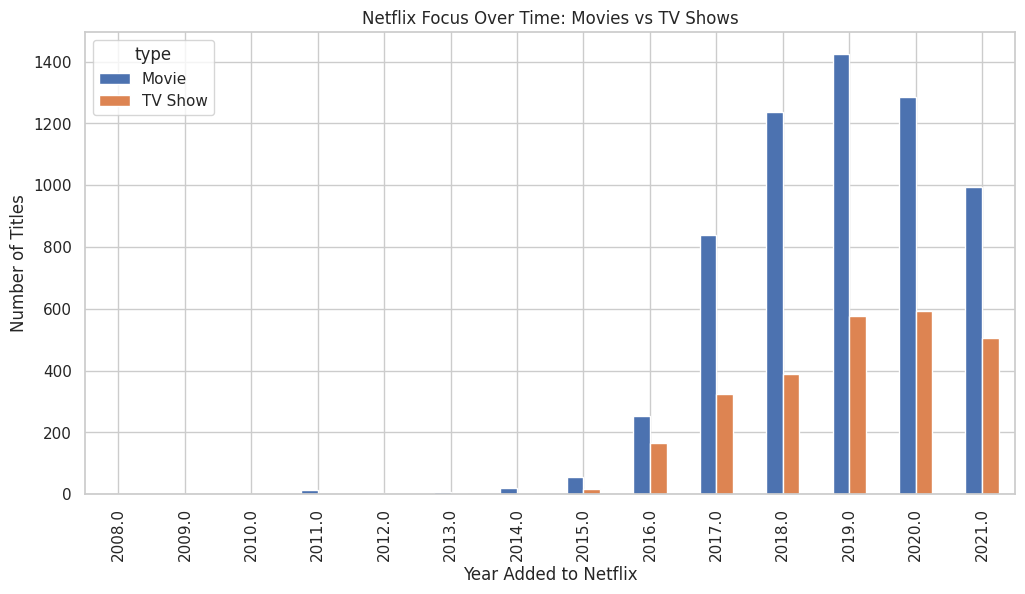

In [ ]:
# Ensure 'year_added' column exists
if 'year_added' not in df.columns:
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['year_added'] = df['date_added'].dt.year

# Drop any rows with missing year
df_year = df[df['year_added'].notnull()]

# Plot trend
trend = df_year.groupby(['year_added', 'type']).size().unstack(fill_value=0)
trend.plot(kind='bar', figsize=(12,6))
plt.title('Netflix Focus Over Time: Movies vs TV Shows')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of Titles')
plt.show()


# 6. Content in different countries

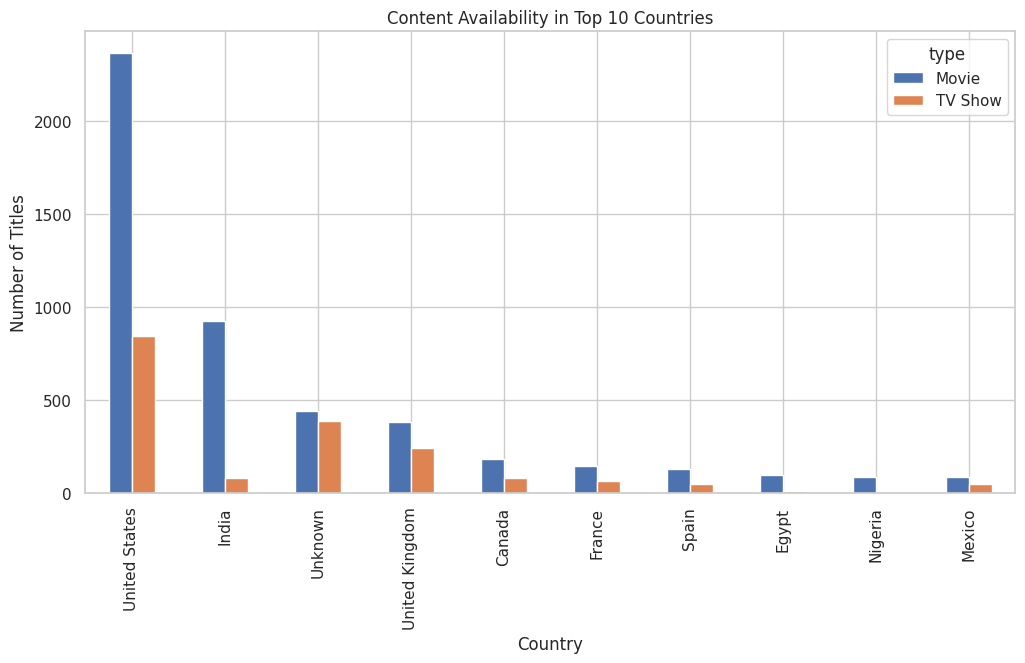

In [ ]:
# Ensure 'main_country' column exists
if 'main_country' not in df.columns:
    # Handle missing countries safely
    df['country'] = df['country'].fillna('Unknown').astype(str)
    df['main_country'] = df['country'].apply(lambda x: x.split(',')[0].strip() if isinstance(x, str) else x)

# Now run the grouped country analysis
top_country_type = (
    df.groupby(['main_country', 'type'])
    .size()
    .unstack(fill_value=0)
    .sort_values('Movie', ascending=False)
    .head(10)
)

top_country_type.plot(kind='bar', figsize=(12,6))
plt.title('Content Availability in Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()


#ACTIONABLE INSIGHTS
* Netflix's catalog is dominated by movies (~70%) but TV shows have grown sharply since 2016.
* Most content carries TV-MA or TV-14 ratings, indicating adult audiences.
* The highest volume of new titles appeared between 2016 and 2019.
* The United States, India, and the UK are leading producers.
* Regional and localized content is expanding, especially from Asian markets.


# CONCLUSION
Netflix has evolved from a movie-centric service into a global platform emphasizing original and regional TV shows.
To maintain growth, Netflix should:
- Continue investing in region-specific content.
- Prioritize launches in the second half of the year (July–December).
- Balance between global hits and localized storytelling for better audience retention.

In [ ]:
print("\nAnalysis Complete")


Analysis Complete
